# Esercizio 2: Confronto tra Insertion Sort e Quick Sort

**Nome:** Andrea
**Cognome:** Petrucci
**Matricola:** 7050922

Questo notebook analizza due algoritmi di ordinamento fondamentali: Insertion Sort e Quick Sort. Esamineremo il loro funzionamento, complessità temporale e prestazioni pratiche attraverso esempi e confronti diretti. L'obiettivo è comprendere le differenze tra i due approcci e identificare i contesti in cui ciascun algoritmo è più efficiente.

In [1]:
import random

def generate_random_array(size):
    """Genera un array di numeri casuali con dimensione in input."""
    return [random.randint(0, 100) for _ in range(size)]

def generate_sorted_array(size):
    """Genera un array già ordinato con dimensione in input."""
    return list(range(size))

## Insertion Sort
Costruisce l'array ordinato un elemento alla volta, inserendo ogni nuovo elemento nella posizione corretta tra quelli già ordinati. È efficiente per array piccoli o quasi ordinati, con complessità temporale $O(n^2)$ nel caso peggiore e $O(n)$ nel caso migliore.

In [2]:
def insertion_sort(arr):
    """Ordina un array utilizzando l'algoritmo Insertion Sort."""
    for j in range(1, len(arr)):
        key = arr[j]
        i = j - 1
        while i >= 0 and key < arr[i]:
            arr[i + 1] = arr[i]
            i -= 1
        arr[i + 1] = key
    return arr

## Quick Sort
È un algoritmo **Divide et Impera** che seleziona un elemento come pivot, partiziona l'array mettendo gli elementi minori a sinistra e i maggiori a destra, e ordina ricorsivamente i sottoarray. La versione classica possiede una complessità temporale media di $O(n \lg n)$, ma precipita a $O(n^2)$ nel caso peggiore (array già ordinati o inversamente ordinati). Per ovviare a questo limite intrinseco, in questa sede è stata implementata la versione randomizzata dell'algoritmo. L'estrazione casuale del pivot svincola le prestazioni dalla disposizione iniziale dei dati, mantenendo l'esecuzione estremamente efficiente nella pratica.

In [3]:
def partition(A,p,r):
    i=p-1
    for j in range (p,r):
        if A[j] <= A[r]:
            i = i+1
            A[i], A[j] = A[j], A[i]
    A[i+1], A[r] = A[r], A[i+1]
    return i+1

def randomized_partition(A,p,r):
    """Sceglie un pivot casuale e lo scambia con A[r] prima della partizione."""
    i = random.randint(p, r)
    A[i], A[r] = A[r], A[i]
    return partition(A,p,r)

def quicksort(A,p,r):
    if p<r:
        q = randomized_partition(A,p,r)
        quicksort(A,p,q-1)
        quicksort(A,q+1,r)

## Benchmark e Confronto
Misuriamo il tempo di esecuzione di Insertion Sort e Quick Sort su array di dimensioni diverse e confrontiamo le prestazioni tramite grafici.

### Prerequisiti di sistema
Per la corretta esecuzione di questo Notebook e la visualizzazione dei grafici, è necessario che nel kernel Python sia installata la libreria `matplotlib`. 
Qualora non fosse presente, è possibile installarla eseguendo il seguente comando in un terminale o in una cella temporanea:
`%pip install matplotlib`

Dimensione	Insertion Sort	Quick Sort
--------------------------------------------------
100		0.000161	0.000084
500		0.004955	0.000972
1000		0.021908	0.001991
2000		0.089479	0.004681
5000		0.600697	0.017841


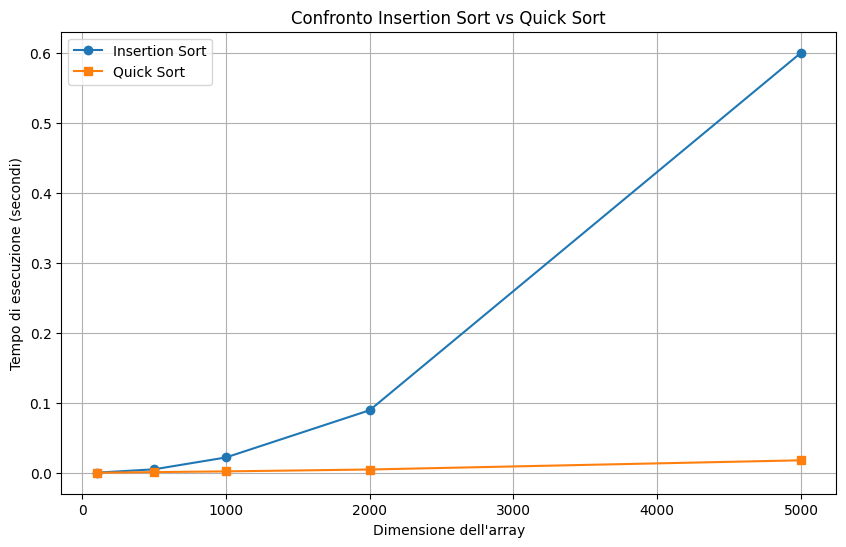

In [4]:
import time
import matplotlib.pyplot as plt

def benchmark_sorting_algorithms():
    """Esegue benchmark su Insertion Sort e Quick Sort e mostra i risultati."""
    sizes = [100, 500, 1000, 2000, 5000]
    insertion_times = []
    quick_times = []

    for size in sizes:
        arr = generate_random_array(size)
        
        # Benchmark Insertion Sort
        arr_copy = arr.copy()
        start = time.time()
        insertion_sort(arr_copy)
        end = time.time()
        insertion_times.append(end - start)
        
        # Benchmark Quick Sort
        arr_copy = arr.copy()
        start = time.time()
        quicksort(arr_copy, 0, len(arr_copy) - 1)
        end = time.time()
        quick_times.append(end - start)
    
    # Stampa risultati
    print("Dimensione\tInsertion Sort\tQuick Sort")
    print("-" * 50)
    for i, size in enumerate(sizes):
        print(f"{size}\t\t{insertion_times[i]:.6f}\t{quick_times[i]:.6f}")
    
    # Crea grafico
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, insertion_times, marker='o', label='Insertion Sort')
    plt.plot(sizes, quick_times, marker='s', label='Quick Sort')
    plt.xlabel('Dimensione dell\'array')
    plt.ylabel('Tempo di esecuzione (secondi)')
    plt.title('Confronto Insertion Sort vs Quick Sort')
    plt.legend()
    plt.grid(True)
    plt.show()

# Esegui benchmark
benchmark_sorting_algorithms()

## Benchmark con Array Ordinato
Testiamo Quick Sort sull'array già ordinato da Insertion Sort per verificare l'efficacia del pivot casuale.

Dimensione	Insertion Sort	Quick Sort su array ordinato
-----------------------------------------------------------------
100		0.000176	0.000087
500		0.004832	0.000620
1000		0.021054	0.001668
2000		0.094793	0.004370
5000		0.625552	0.019665


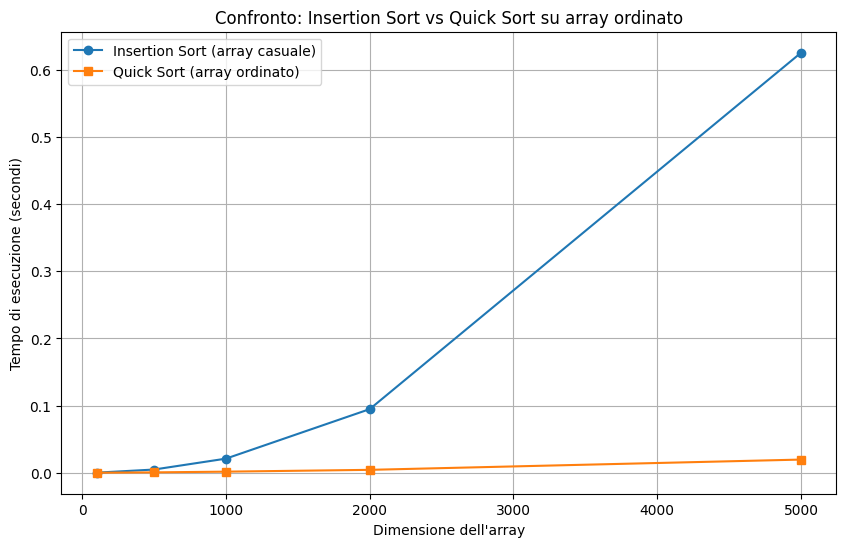

In [5]:
def benchmark_sorted_array():
    """Benchmark dove Quick Sort usa l'array già ordinato da Insertion Sort."""
    sizes = [100, 500, 1000, 2000, 5000]
    insertion_times = []
    quick_on_sorted_times = []

    for size in sizes:
        arr = generate_random_array(size)
        
        # Insertion Sort sull'array casuale
        arr_copy = arr.copy()
        start = time.time()
        insertion_sort(arr_copy)
        end = time.time()
        insertion_times.append(end - start)
        
        # Quick Sort sull'array GIÀ ORDINATO (lo stesso di Insertion Sort)
        start = time.time()
        quicksort(arr_copy, 0, len(arr_copy) - 1)
        end = time.time()
        quick_on_sorted_times.append(end - start)
    
    # Stampa risultati
    print("Dimensione\tInsertion Sort\tQuick Sort su array ordinato")
    print("-" * 65)
    for i, size in enumerate(sizes):
        print(f"{size}\t\t{insertion_times[i]:.6f}\t{quick_on_sorted_times[i]:.6f}")
    
    # Crea grafico (solo se matplotlib è disponibile)
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.plot(sizes, insertion_times, marker='o', label='Insertion Sort (array casuale)')
        plt.plot(sizes, quick_on_sorted_times, marker='s', label='Quick Sort (array ordinato)')
        plt.xlabel('Dimensione dell\'array')
        plt.ylabel('Tempo di esecuzione (secondi)')
        plt.title('Confronto: Insertion Sort vs Quick Sort su array ordinato')
        plt.legend()
        plt.grid(True)
        plt.show()
    except ImportError:
        print("\nMatplotlib non installato, impossibile visualizzare il grafico.")

# Esegui benchmark
benchmark_sorted_array()

## Benchmark con Entrambi gli Algoritmi su Array Ordinato
Testiamo sia Insertion Sort che Quick Sort su un array già ordinato, per confrontare le loro prestazioni nel caso migliore per Insertion Sort.

Dimensione	Insertion Sort	Quick Sort
		(array ordinato)	(array ordinato)
-----------------------------------------------------------------
100		0.000009	0.000091
500		0.000045	0.000611
1000		0.000098	0.001469
2000		0.000200	0.003094
5000		0.000689	0.008269


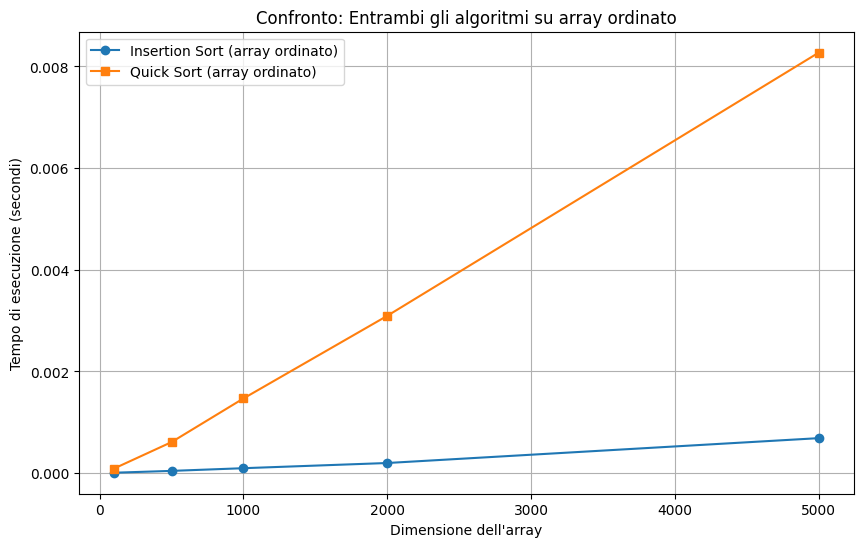

In [6]:
def benchmark_both_on_sorted():
    """Benchmark dove entrambi gli algoritmi ricevono un array già ordinato."""
    sizes = [100, 500, 1000, 2000, 5000]
    insertion_sorted_times = []
    quick_sorted_times = []

    for size in sizes:
        # Genera array già ordinato
        arr = generate_sorted_array(size)
        
        # Insertion Sort sull'array già ordinato (caso migliore)
        arr_copy = arr.copy()
        start = time.time()
        insertion_sort(arr_copy)
        end = time.time()
        insertion_sorted_times.append(end - start)
        
        # Quick Sort sull'array già ordinato
        arr_copy = arr.copy()
        start = time.time()
        quicksort(arr_copy, 0, len(arr_copy) - 1)
        end = time.time()
        quick_sorted_times.append(end - start)
    
    # Stampa risultati
    print("Dimensione\tInsertion Sort\tQuick Sort")
    print("\t\t(array ordinato)\t(array ordinato)")
    print("-" * 65)
    for i, size in enumerate(sizes):
        print(f"{size}\t\t{insertion_sorted_times[i]:.6f}\t{quick_sorted_times[i]:.6f}")
    
    # Crea grafico (solo se matplotlib è disponibile)
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.plot(sizes, insertion_sorted_times, marker='o', label='Insertion Sort (array ordinato)')
        plt.plot(sizes, quick_sorted_times, marker='s', label='Quick Sort (array ordinato)')
        plt.xlabel('Dimensione dell\'array')
        plt.ylabel('Tempo di esecuzione (secondi)')
        plt.title('Confronto: Entrambi gli algoritmi su array ordinato')
        plt.legend()
        plt.grid(True)
        plt.show()
    except ImportError:
        print("\nMatplotlib non installato, impossibile visualizzare il grafico.")

# Esegui benchmark
benchmark_both_on_sorted()